<a href="https://colab.research.google.com/github/messycodechaos/v3/blob/main/Multimodal_Eye_Disease_RAG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os

DATASET_PATH = "/content/drive/MyDrive/eyesdataset"
print(os.path.exists(DATASET_PATH))

Mounted at /content/drive
True


In [2]:
folders = sorted(os.listdir(DATASET_PATH))

print("Number of items:", len(folders))
print("\nDataset folders:")

for i, folder in enumerate(folders, start=1):
    print(i, folder)

Number of items: 11

Dataset folders:
1 Central Serous Chorioretinopathy [Color Fundus]
2 Disc Edema
3 Macular Scar
4 Myopia
5 Pterygium
6 Retinal Detachment
7 Retinitis Pigmentosa
8 cataract
9 diabetic_retinopathy
10 glaucoma
11 normal


In [3]:
image_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')

class_counts = {}
total_images = 0

for class_name in sorted(os.listdir(DATASET_PATH)):

    class_path = os.path.join(DATASET_PATH, class_name)

    if os.path.isdir(class_path):

        images = [
            file for file in os.listdir(class_path)
            if file.lower().endswith(image_extensions)
        ]

        class_counts[class_name] = len(images)
        total_images += len(images)

        print(f"{class_name}: {len(images)} images")

print("\n---------------------------")
print("Number of classes:", len(class_counts))
print("Total images:", total_images)
print("---------------------------")

Central Serous Chorioretinopathy [Color Fundus]: 101 images
Disc Edema: 127 images
Macular Scar: 444 images
Myopia: 500 images
Pterygium: 17 images
Retinal Detachment: 125 images
Retinitis Pigmentosa: 139 images
cataract: 1039 images
diabetic_retinopathy: 2470 images
glaucoma: 2257 images
normal: 1074 images

---------------------------
Number of classes: 11
Total images: 8293
---------------------------


In [4]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

print("Libraries imported successfully.")

Libraries imported successfully.


In [5]:
classes = sorted([
    folder for folder in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, folder))
])

print("Classes found:", len(classes))
print(classes)

Classes found: 11
['Central Serous Chorioretinopathy [Color Fundus]', 'Disc Edema', 'Macular Scar', 'Myopia', 'Pterygium', 'Retinal Detachment', 'Retinitis Pigmentosa', 'cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']


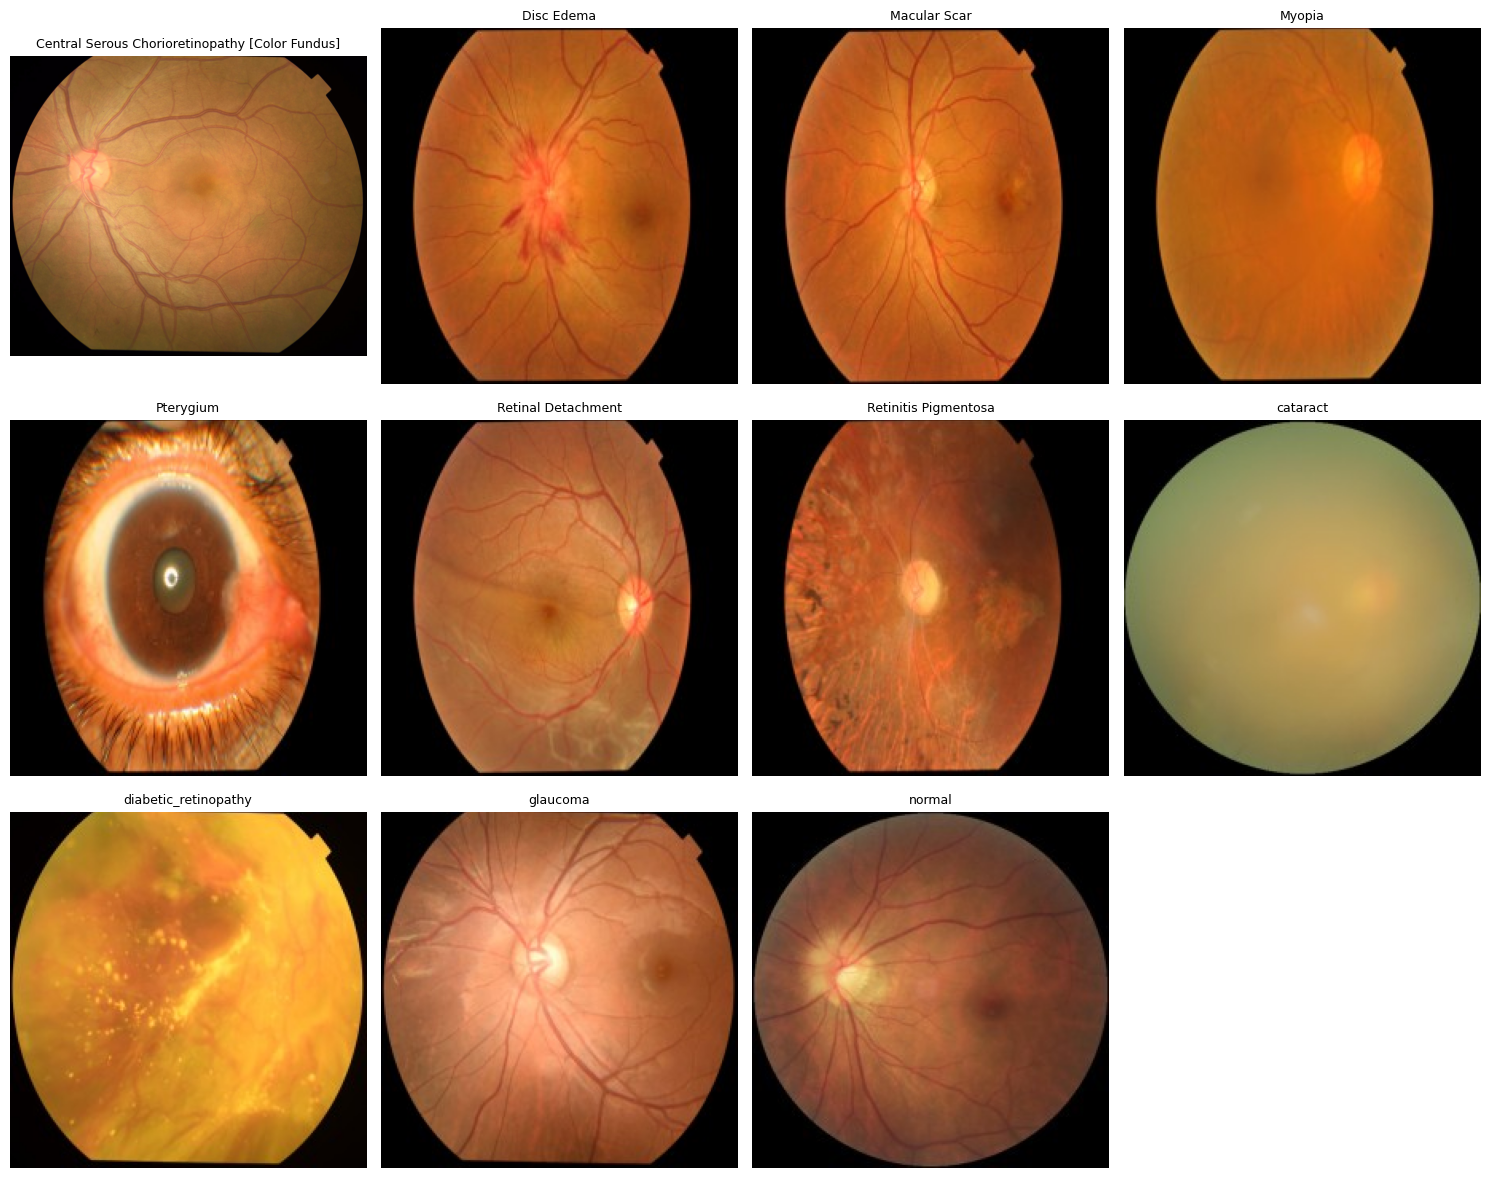

In [6]:
image_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')

plt.figure(figsize=(15, 12))

for i, class_name in enumerate(classes):

    class_path = os.path.join(DATASET_PATH, class_name)

    images = [
        file for file in os.listdir(class_path)
        if file.lower().endswith(image_extensions)
    ]

    if len(images) == 0:
        print(f"No images found in: {class_name}")
        continue

    image_name = random.choice(images)
    image_path = os.path.join(class_path, image_name)

    image = Image.open(image_path).convert("RGB")

    plt.subplot(3, 4, i + 1)
    plt.imshow(image)
    plt.title(class_name, fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
from PIL import Image

corrupted_images = []

for class_name in classes:

    class_path = os.path.join(DATASET_PATH, class_name)

    for file in os.listdir(class_path):

        if file.lower().endswith(image_extensions):

            image_path = os.path.join(class_path, file)

            try:
                with Image.open(image_path) as img:
                    img.verify()

            except Exception as e:
                corrupted_images.append(image_path)

print("Corrupted images found:", len(corrupted_images))

if corrupted_images:
    print("\nCorrupted files:")
    for path in corrupted_images:
        print(path)
else:
    print("✓ All images passed the corruption check.")

Corrupted images found: 0
✓ All images passed the corruption check.


In [8]:
sizes = {}

for class_name in classes:

    class_path = os.path.join(DATASET_PATH, class_name)

    for file in os.listdir(class_path):

        if file.lower().endswith(image_extensions):

            image_path = os.path.join(class_path, file)

            try:
                with Image.open(image_path) as img:
                    sizes[img.size] = sizes.get(img.size, 0) + 1
            except:
                pass

print("Number of different image dimensions:", len(sizes))

print("\nMost common image sizes:")

for size, count in sorted(
    sizes.items(),
    key=lambda x: x[1],
    reverse=True
)[:10]:
    print(size, ":", count, "images")

Number of different image dimensions: 7

Most common image sizes:
(224, 224) : 6735 images
(512, 512) : 1233 images
(2592, 1728) : 150 images
(2004, 1690) : 101 images
(2464, 1632) : 41 images
(256, 256) : 23 images
(1848, 1224) : 10 images


In [9]:
# ============================================================
# STEP 4: FUNDUS IMAGE PREPROCESSING
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

print("OpenCV version:", cv2.__version__)
print("Preprocessing libraries loaded successfully.")

OpenCV version: 5.0.0
Preprocessing libraries loaded successfully.


In [10]:
IMG_SIZE = 224

def preprocess_fundus(image_path):

    # Read image
    image = cv2.imread(image_path)

    if image is None:
        raise ValueError(f"Could not read image: {image_path}")

    # OpenCV uses BGR, convert to RGB
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Resize
    image = cv2.resize(
        image,
        (IMG_SIZE, IMG_SIZE),
        interpolation=cv2.INTER_AREA
    )

    # Convert RGB -> LAB
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)

    # Separate channels
    l, a, b = cv2.split(lab)

    # CLAHE enhancement
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    l_enhanced = clahe.apply(l)

    # Merge channels
    enhanced_lab = cv2.merge(
        (l_enhanced, a, b)
    )

    # Convert back to RGB
    enhanced_image = cv2.cvtColor(
        enhanced_lab,
        cv2.COLOR_LAB2RGB
    )

    return image, enhanced_image


print("Preprocessing function created successfully.")

Preprocessing function created successfully.


In [11]:
import random

# Select a random disease class
selected_class = random.choice(classes)

class_path = os.path.join(
    DATASET_PATH,
    selected_class
)

images = [
    f for f in os.listdir(class_path)
    if f.lower().endswith(image_extensions)
]

selected_image = random.choice(images)

image_path = os.path.join(
    class_path,
    selected_image
)

print("Disease class:", selected_class)
print("Image:", selected_image)
print("Path:", image_path)

Disease class: normal
Image: 413_normal.jpg
Path: /content/drive/MyDrive/eyesdataset/normal/413_normal.jpg


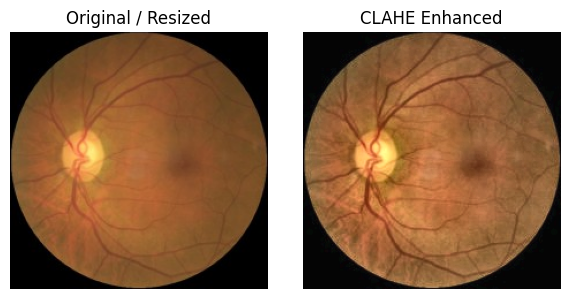

In [12]:
original, enhanced = preprocess_fundus(image_path)

plt.figure(figsize=(6, 3))

plt.subplot(1, 2, 1)
plt.imshow(original)
plt.title("Original / Resized")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(enhanced)
plt.title("CLAHE Enhanced")
plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
normalized_image = enhanced.astype(np.float32) / 255.0

print("Image shape:", normalized_image.shape)
print("Data type:", normalized_image.dtype)
print("Minimum value:", normalized_image.min())
print("Maximum value:", normalized_image.max())

Image shape: (224, 224, 3)
Data type: float32
Minimum value: 0.0
Maximum value: 1.0


In [14]:
# ============================================================
# STEP 5: TRAIN / VALIDATION / TEST SPLIT
# ============================================================

import os
import pandas as pd
from sklearn.model_selection import train_test_split

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [15]:
data = []

for class_name in classes:

    class_path = os.path.join(DATASET_PATH, class_name)

    for file_name in os.listdir(class_path):

        if file_name.lower().endswith(image_extensions):

            image_path = os.path.join(
                class_path,
                file_name
            )

            data.append({
                "image_path": image_path,
                "label": class_name
            })

df = pd.DataFrame(data)

print("Total images:", len(df))
print("Total classes:", df["label"].nunique())

df.head()

Total images: 8293
Total classes: 11


,image_path,label
0,/content/drive/MyDrive/eyesdataset/Central Ser...,Central Serous Chorioretinopathy [Color Fundus]
1,/content/drive/MyDrive/eyesdataset/Central Ser...,Central Serous Chorioretinopathy [Color Fundus]
2,/content/drive/MyDrive/eyesdataset/Central Ser...,Central Serous Chorioretinopathy [Color Fundus]
3,/content/drive/MyDrive/eyesdataset/Central Ser...,Central Serous Chorioretinopathy [Color Fundus]
4,/content/drive/MyDrive/eyesdataset/Central Ser...,Central Serous Chorioretinopathy [Color Fundus]


In [16]:
class_distribution = (
    df["label"]
    .value_counts()
    .sort_index()
)

print(class_distribution)

label
Central Serous Chorioretinopathy [Color Fundus]     101
Disc Edema                                          127
Macular Scar                                        444
Myopia                                              500
Pterygium                                            17
Retinal Detachment                                  125
Retinitis Pigmentosa                                139
cataract                                           1039
diabetic_retinopathy                               2470
glaucoma                                           2257
normal                                             1074
Name: count, dtype: int64


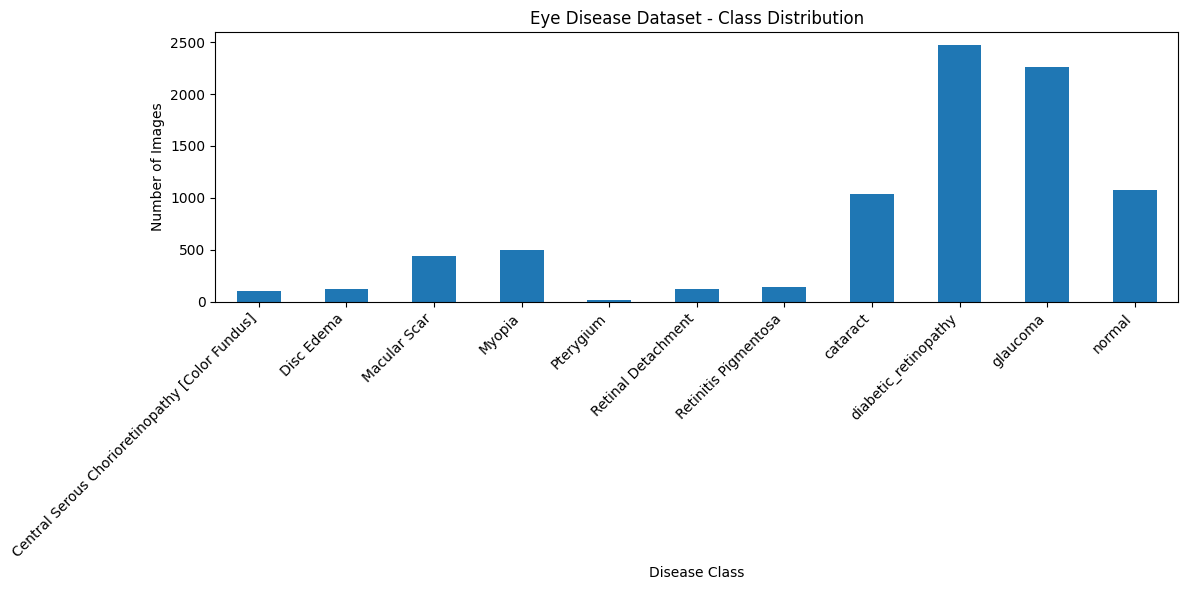

In [17]:
plt.figure(figsize=(12, 6))

class_distribution.plot(kind="bar")

plt.title("Eye Disease Dataset - Class Distribution")
plt.xlabel("Disease Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [18]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df["label"]
)

In [19]:
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label"]
)

In [20]:
print("Total images :", len(df))

print("\nTraining images   :", len(train_df))
print("Validation images :", len(val_df))
print("Testing images    :", len(test_df))

print("\nPercentages")

print("Training:",
      round(len(train_df) / len(df) * 100, 2), "%")

print("Validation:",
      round(len(val_df) / len(df) * 100, 2), "%")

print("Testing:",
      round(len(test_df) / len(df) * 100, 2), "%")

Total images : 8293

Training images   : 5805
Validation images : 1244
Testing images    : 1244

Percentages
Training: 70.0 %
Validation: 15.0 %
Testing: 15.0 %


In [21]:
split_distribution = pd.DataFrame({
    "Total": df["label"].value_counts(),
    "Train": train_df["label"].value_counts(),
    "Validation": val_df["label"].value_counts(),
    "Test": test_df["label"].value_counts()
}).fillna(0).astype(int)

split_distribution

,Total,Train,Validation,Test
label,,,,
Central Serous Chorioretinopathy [Color Fundus],101,71,15,15
Disc Edema,127,89,19,19
Macular Scar,444,311,67,66
Myopia,500,350,75,75
Pterygium,17,12,3,2
Retinal Detachment,125,87,19,19
Retinitis Pigmentosa,139,97,21,21
cataract,1039,727,156,156
diabetic_retinopathy,2470,1729,370,371


In [22]:
train_paths = set(train_df["image_path"])
val_paths = set(val_df["image_path"])
test_paths = set(test_df["image_path"])

print(
    "Train ↔ Validation overlap:",
    len(train_paths.intersection(val_paths))
)

print(
    "Train ↔ Test overlap:",
    len(train_paths.intersection(test_paths))
)

print(
    "Validation ↔ Test overlap:",
    len(val_paths.intersection(test_paths))
)

Train ↔ Validation overlap: 0
Train ↔ Test overlap: 0
Validation ↔ Test overlap: 0


In [23]:
# ============================================================
# STEP 6: PYTORCH DATASET AND DATALOADERS
# ============================================================

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

print("PyTorch version:", torch.__version__)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

PyTorch version: 2.11.0+cu128
Device: cuda


In [24]:
class_names = sorted(df["label"].unique())

class_to_idx = {
    class_name: idx
    for idx, class_name in enumerate(class_names)
}

idx_to_class = {
    idx: class_name
    for class_name, idx in class_to_idx.items()
}

print("Number of classes:", len(class_names))

for class_name, idx in class_to_idx.items():
    print(idx, "->", class_name)

Number of classes: 11
0 -> Central Serous Chorioretinopathy [Color Fundus]
1 -> Disc Edema
2 -> Macular Scar
3 -> Myopia
4 -> Pterygium
5 -> Retinal Detachment
6 -> Retinitis Pigmentosa
7 -> cataract
8 -> diabetic_retinopathy
9 -> glaucoma
10 -> normal


In [25]:
IMG_SIZE = 224

train_transform = transforms.Compose([

    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    # Mild augmentation
    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [26]:
eval_transform = transforms.Compose([

    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [27]:
class EyeDiseaseDataset(Dataset):

    def __init__(self, dataframe, transform=None):

        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):

        return len(self.dataframe)

    def __getitem__(self, idx):

        image_path = self.dataframe.loc[
            idx, "image_path"
        ]

        label_name = self.dataframe.loc[
            idx, "label"
        ]

        # Open image
        image = Image.open(
            image_path
        ).convert("RGB")

        # Convert class name to number
        label = class_to_idx[label_name]

        # Apply transformations
        if self.transform:
            image = self.transform(image)

        return image, label


print("EyeDiseaseDataset class created.")

EyeDiseaseDataset class created.


In [28]:
train_dataset = EyeDiseaseDataset(
    train_df,
    transform=train_transform
)

val_dataset = EyeDiseaseDataset(
    val_df,
    transform=eval_transform
)

test_dataset = EyeDiseaseDataset(
    test_df,
    transform=eval_transform
)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Testing samples:", len(test_dataset))

Training samples: 5805
Validation samples: 1244
Testing samples: 1244


In [29]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("DataLoaders created successfully.")

DataLoaders created successfully.


In [30]:
# Create class-to-number mapping

class_names = sorted(df["label"].unique())

class_to_idx = {
    class_name: idx
    for idx, class_name in enumerate(class_names)
}

idx_to_class = {
    idx: class_name
    for class_name, idx in class_to_idx.items()
}

print("Number of classes:", len(class_names))
print("\nClass mapping:")

for class_name, idx in class_to_idx.items():
    print(f"{idx} -> {class_name}")

Number of classes: 11

Class mapping:
0 -> Central Serous Chorioretinopathy [Color Fundus]
1 -> Disc Edema
2 -> Macular Scar
3 -> Myopia
4 -> Pterygium
5 -> Retinal Detachment
6 -> Retinitis Pigmentosa
7 -> cataract
8 -> diabetic_retinopathy
9 -> glaucoma
10 -> normal


In [31]:
image, label = train_dataset[0]

print("SUCCESS!")
print("Image shape:", image.shape)
print("Label number:", label)
print("Disease:", idx_to_class[label])

SUCCESS!
Image shape: torch.Size([3, 224, 224])
Label number: 10
Disease: normal


In [32]:
images, labels = next(iter(train_loader))

print("Batch loaded successfully!")
print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

print("\nFirst 10 labels:")
print(labels[:10])

Batch loaded successfully!
Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])

First 10 labels:
tensor([9, 8, 7, 2, 9, 3, 8, 9, 7, 8])


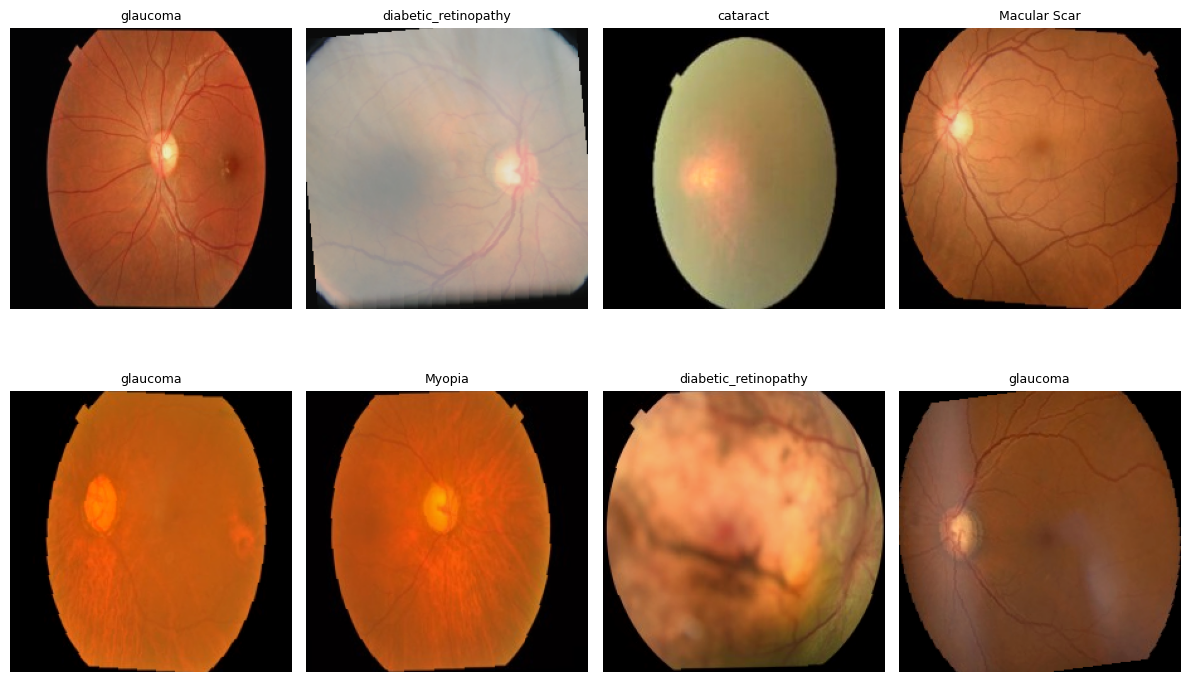

In [33]:
import matplotlib.pyplot as plt
import numpy as np

mean = np.array(
    [0.485, 0.456, 0.406]
)

std = np.array(
    [0.229, 0.224, 0.225]
)

plt.figure(figsize=(12, 8))

for i in range(min(8, len(images))):

    img = images[i].permute(
        1, 2, 0
    ).numpy()

    # Reverse normalization
    img = std * img + mean

    img = np.clip(
        img,
        0,
        1
    )

    label_number = labels[i].item()
    disease_name = idx_to_class[label_number]

    plt.subplot(2, 4, i + 1)

    plt.imshow(img)

    plt.title(
        disease_name,
        fontsize=9
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [34]:
train_counts = (
    train_df["label"]
    .value_counts()
    .reindex(class_names)
)

print(train_counts)

label
Central Serous Chorioretinopathy [Color Fundus]      71
Disc Edema                                           89
Macular Scar                                        311
Myopia                                              350
Pterygium                                            12
Retinal Detachment                                   87
Retinitis Pigmentosa                                 97
cataract                                            727
diabetic_retinopathy                               1729
glaucoma                                           1580
normal                                              752
Name: count, dtype: int64


In [35]:
# ============================================================
# STEP 7: BASELINE MODEL - EFFICIENTNET-B0
# ============================================================

import torch
import torch.nn as nn
from torchvision import models

# Load pretrained EfficientNet-B0
weights = models.EfficientNet_B0_Weights.DEFAULT

model = models.efficientnet_b0(weights=weights)

print("EfficientNet-B0 loaded successfully.")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 125MB/s]


EfficientNet-B0 loaded successfully.


In [36]:
NUM_CLASSES = len(class_names)

print("Number of eye classes:", NUM_CLASSES)

in_features = model.classifier[1].in_features

model.classifier[1] = nn.Linear(
    in_features,
    NUM_CLASSES
)

model = model.to(device)

print("Model modified successfully.")
print("Output classes:", NUM_CLASSES)

Number of eye classes: 11
Model modified successfully.
Output classes: 11


In [37]:
for param in model.features.parameters():
    param.requires_grad = False

print("Feature extractor frozen.")

Feature extractor frozen.


In [38]:
trainable = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

total = sum(
    p.numel()
    for p in model.parameters()
)

print("Total parameters:", f"{total:,}")
print("Trainable parameters:", f"{trainable:,}")

Total parameters: 4,021,639
Trainable parameters: 14,091


In [39]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

train_labels = train_df["label"].values

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array(class_names),
    y=train_labels
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

print("Class weights:")

for name, weight in zip(class_names, class_weights):
    print(
        f"{name:45s} : "
        f"{weight.item():.4f}"
    )

Class weights:
Central Serous Chorioretinopathy [Color Fundus] : 7.4328
Disc Edema                                    : 5.9295
Macular Scar                                  : 1.6969
Myopia                                        : 1.5078
Pterygium                                     : 43.9773
Retinal Detachment                            : 6.0658
Retinitis Pigmentosa                          : 5.4405
cataract                                      : 0.7259
diabetic_retinopathy                          : 0.3052
glaucoma                                      : 0.3340
normal                                        : 0.7018


In [40]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

print("Weighted CrossEntropyLoss created.")

Weighted CrossEntropyLoss created.


In [41]:
optimizer = torch.optim.AdamW(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=1e-3,
    weight_decay=1e-4
)

print("AdamW optimizer created.")

AdamW optimizer created.


In [42]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

print("Scheduler created.")

Scheduler created.


In [43]:
images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(images)

print("Input shape :", images.shape)
print("Output shape:", outputs.shape)

Input shape : torch.Size([32, 3, 224, 224])
Output shape: torch.Size([32, 11])


In [44]:
with torch.no_grad():

    probabilities = torch.softmax(
        outputs,
        dim=1
    )

    predicted_idx = torch.argmax(
        probabilities[0]
    ).item()

    confidence = probabilities[
        0,
        predicted_idx
    ].item()

actual_idx = labels[0].item()

print(
    "Actual:",
    idx_to_class[actual_idx]
)

print(
    "Predicted:",
    idx_to_class[predicted_idx]
)

print(
    f"Confidence: {confidence * 100:.2f}%"
)

Actual: cataract
Predicted: Disc Edema
Confidence: 12.37%


In [45]:
# ============================================================
# STEP 8: MODEL TRAINING AND VALIDATION
# ============================================================

import torch
import numpy as np
from sklearn.metrics import accuracy_score, f1_score
import time

print("Training libraries loaded.")

Training libraries loaded.


In [46]:
def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    all_predictions = []
    all_labels = []

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        # Clear old gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        all_predictions.extend(
            predictions.detach().cpu().numpy()
        )

        all_labels.extend(
            labels.detach().cpu().numpy()
        )

    epoch_loss = running_loss / len(loader.dataset)

    epoch_accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    epoch_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    return epoch_loss, epoch_accuracy, epoch_f1

In [47]:
def validate_model(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0
    all_predictions = []
    all_labels = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_loss += (
                loss.item() * images.size(0)
            )

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

    epoch_loss = (
        running_loss /
        len(loader.dataset)
    )

    epoch_accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    epoch_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    return epoch_loss, epoch_accuracy, epoch_f1

In [48]:
NUM_EPOCHS = 10
PATIENCE = 3

best_val_loss = float("inf")
patience_counter = 0

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

train_f1_scores = []
val_f1_scores = []

print("Training configuration ready.")

Training configuration ready.


In [49]:
MODEL_PATH = "/content/drive/MyDrive/best_eye_model.pth"

print("Best model will be saved to:")
print(MODEL_PATH)

Best model will be saved to:
/content/drive/MyDrive/best_eye_model.pth


In [50]:
for epoch in range(NUM_EPOCHS):

    start_time = time.time()

    print("\n" + "=" * 60)
    print(f"Epoch {epoch + 1}/{NUM_EPOCHS}")
    print("=" * 60)

    # -------------------------
    # TRAIN
    # -------------------------

    train_loss, train_acc, train_f1 = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    # -------------------------
    # VALIDATION
    # -------------------------

    val_loss, val_acc, val_f1 = validate_model(
        model,
        val_loader,
        criterion,
        device
    )

    # Update scheduler
    scheduler.step(val_loss)

    # Save history
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    train_f1_scores.append(train_f1)
    val_f1_scores.append(val_f1)

    elapsed = time.time() - start_time

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Accuracy: {train_acc:.4f} | "
        f"Train F1: {train_f1:.4f}"
    )

    print(
        f"Val Loss:   {val_loss:.4f} | "
        f"Val Accuracy: {val_acc:.4f} | "
        f"Val F1: {val_f1:.4f}"
    )

    print(
        f"Time: {elapsed / 60:.2f} minutes"
    )

    # -------------------------
    # SAVE BEST MODEL
    # -------------------------

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        patience_counter = 0

        torch.save(
            model.state_dict(),
            MODEL_PATH
        )

        print("✓ Best model saved!")

    else:

        patience_counter += 1

        print(
            f"No validation improvement "
            f"({patience_counter}/{PATIENCE})"
        )

    # -------------------------
    # EARLY STOPPING
    # -------------------------

    if patience_counter >= PATIENCE:

        print("\nEarly stopping triggered.")
        break


Epoch 1/10
Train Loss: 1.4710 | Train Accuracy: 0.4720 | Train F1: 0.4069
Val Loss:   1.0820 | Val Accuracy: 0.6294 | Val F1: 0.6139
Time: 1.61 minutes
✓ Best model saved!

Epoch 2/10
Train Loss: 0.9395 | Train Accuracy: 0.5922 | Train F1: 0.5650
Val Loss:   0.9205 | Val Accuracy: 0.6174 | Val F1: 0.5947
Time: 1.40 minutes
✓ Best model saved!

Epoch 3/10
Train Loss: 0.8279 | Train Accuracy: 0.6184 | Train F1: 0.5820
Val Loss:   0.8695 | Val Accuracy: 0.6391 | Val F1: 0.6188
Time: 1.40 minutes
✓ Best model saved!

Epoch 4/10
Train Loss: 0.7618 | Train Accuracy: 0.6450 | Train F1: 0.6310
Val Loss:   0.8154 | Val Accuracy: 0.6592 | Val F1: 0.6248
Time: 1.40 minutes
✓ Best model saved!

Epoch 5/10
Train Loss: 0.6940 | Train Accuracy: 0.6613 | Train F1: 0.6338
Val Loss:   0.7710 | Val Accuracy: 0.6600 | Val F1: 0.6353
Time: 1.40 minutes
✓ Best model saved!

Epoch 6/10
Train Loss: 0.6812 | Train Accuracy: 0.6674 | Train F1: 0.6442
Val Loss:   0.7753 | Val Accuracy: 0.6270 | Val F1: 0.6190
T

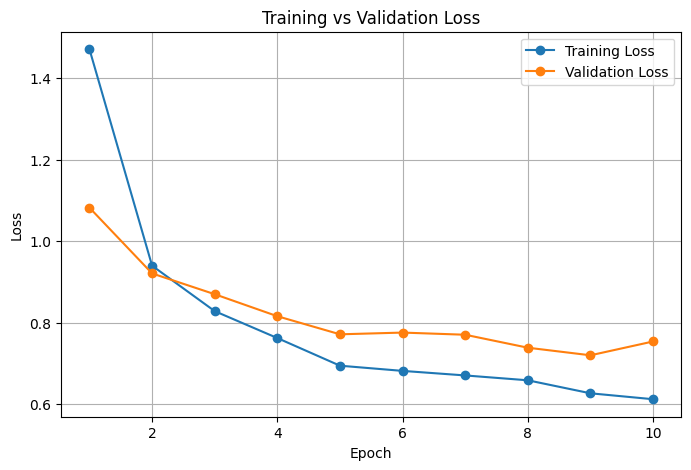

In [51]:
import matplotlib.pyplot as plt

epochs_completed = range(
    1,
    len(train_losses) + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_completed,
    train_losses,
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs_completed,
    val_losses,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()

plt.show()

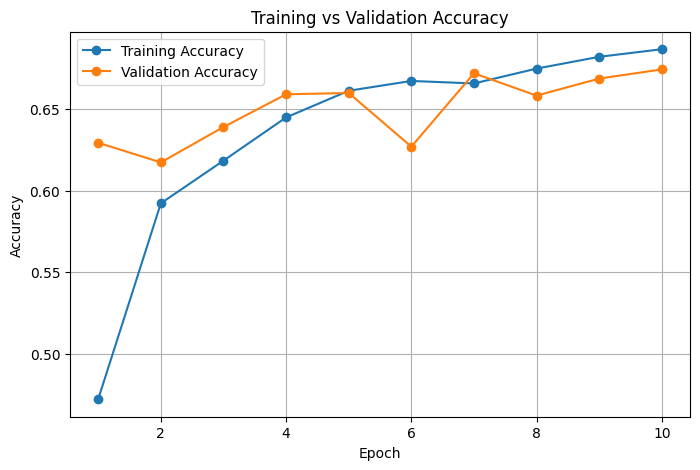

In [52]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs_completed,
    train_accuracies,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs_completed,
    val_accuracies,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid()

plt.show()

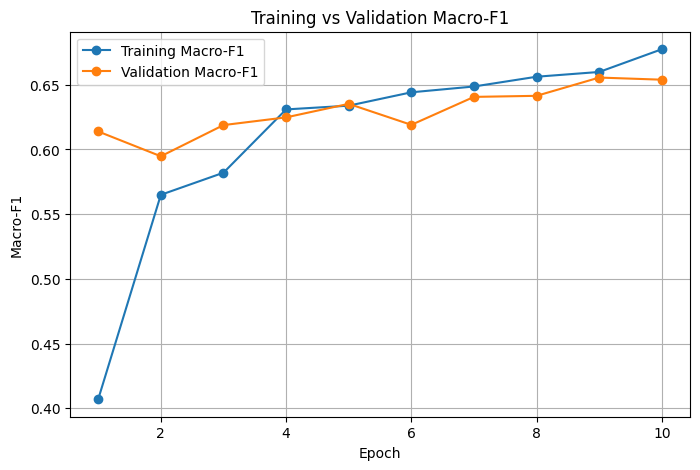

In [53]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs_completed,
    train_f1_scores,
    marker="o",
    label="Training Macro-F1"
)

plt.plot(
    epochs_completed,
    val_f1_scores,
    marker="o",
    label="Validation Macro-F1"
)

plt.xlabel("Epoch")
plt.ylabel("Macro-F1")
plt.title("Training vs Validation Macro-F1")
plt.legend()
plt.grid()

plt.show()

In [54]:
model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=device
    )
)

model = model.to(device)
model.eval()

print("✓ Best model loaded successfully.")

✓ Best model loaded successfully.


In [56]:
# ============================================================
# STEP 9: FINAL TEST EVALUATION
# ============================================================

import torch

model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/best_eye_model.pth",
        map_location=device
    )
)

model = model.to(device)
model.eval()

print("Best model loaded successfully.")

Best model loaded successfully.


In [57]:
all_labels = []
all_predictions = []
all_probabilities = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        predictions = torch.argmax(
            probabilities,
            dim=1
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_probabilities.extend(
            probabilities.cpu().numpy()
        )

print("Test predictions completed.")

print("Number of test images:", len(all_labels))

Test predictions completed.
Number of test images: 1244


In [58]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

test_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

test_precision = precision_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

test_recall = recall_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

test_f1 = f1_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

print("FINAL TEST RESULTS")
print("------------------------------")

print(
    f"Accuracy  : {test_accuracy:.4f} "
    f"({test_accuracy*100:.2f}%)"
)

print(
    f"Precision : {test_precision:.4f} "
    f"({test_precision*100:.2f}%)"
)

print(
    f"Recall    : {test_recall:.4f} "
    f"({test_recall*100:.2f}%)"
)

print(
    f"Macro F1  : {test_f1:.4f} "
    f"({test_f1*100:.2f}%)"
)

FINAL TEST RESULTS
------------------------------
Accuracy  : 0.6929 (69.29%)
Precision : 0.6294 (62.94%)
Recall    : 0.7975 (79.75%)
Macro F1  : 0.6746 (67.46%)


In [59]:
from sklearn.metrics import classification_report

report = classification_report(
    all_labels,
    all_predictions,
    labels=list(range(len(class_names))),
    target_names=class_names,
    digits=4,
    zero_division=0
)

print(report)

                                                 precision    recall  f1-score   support

Central Serous Chorioretinopathy [Color Fundus]     0.5556    1.0000    0.7143        15
                                     Disc Edema     0.4667    0.7368    0.5714        19
                                   Macular Scar     0.3077    0.6061    0.4082        66
                                         Myopia     0.4634    0.7600    0.5758        75
                                      Pterygium     1.0000    1.0000    1.0000         2
                             Retinal Detachment     0.5333    0.8421    0.6531        19
                           Retinitis Pigmentosa     0.3273    0.8571    0.4737        21
                                       cataract     0.7656    0.9423    0.8448       156
                           diabetic_retinopathy     0.9328    0.6739    0.7825       371
                                       glaucoma     0.8663    0.4779    0.6160       339
                    

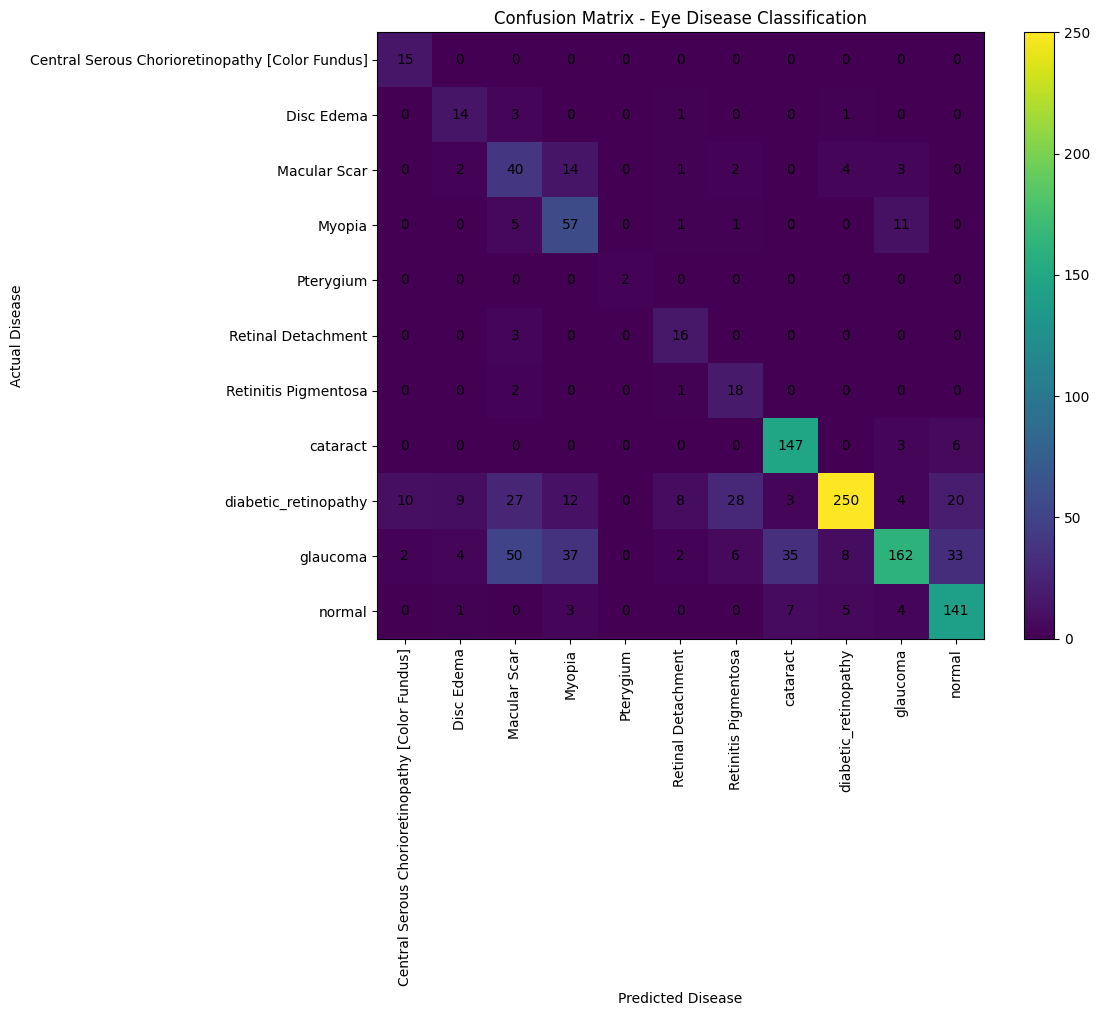

In [60]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(
    all_labels,
    all_predictions,
    labels=list(range(len(class_names)))
)

plt.figure(figsize=(12, 10))

plt.imshow(cm)

plt.title(
    "Confusion Matrix - Eye Disease Classification"
)

plt.xlabel("Predicted Disease")
plt.ylabel("Actual Disease")

plt.xticks(
    np.arange(len(class_names)),
    class_names,
    rotation=90
)

plt.yticks(
    np.arange(len(class_names)),
    class_names
)

plt.colorbar()

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [61]:
sensitivities = []
specificities = []

for i, class_name in enumerate(class_names):

    TP = cm[i, i]

    FN = cm[i, :].sum() - TP

    FP = cm[:, i].sum() - TP

    TN = cm.sum() - (TP + FN + FP)

    sensitivity = (
        TP / (TP + FN)
        if (TP + FN) > 0
        else 0
    )

    specificity = (
        TN / (TN + FP)
        if (TN + FP) > 0
        else 0
    )

    sensitivities.append(sensitivity)
    specificities.append(specificity)

    print(
        f"{class_name}\n"
        f"  Sensitivity: {sensitivity:.4f}\n"
        f"  Specificity: {specificity:.4f}\n"
    )

Central Serous Chorioretinopathy [Color Fundus]
  Sensitivity: 1.0000
  Specificity: 0.9902

Disc Edema
  Sensitivity: 0.7368
  Specificity: 0.9869

Macular Scar
  Sensitivity: 0.6061
  Specificity: 0.9236

Myopia
  Sensitivity: 0.7600
  Specificity: 0.9435

Pterygium
  Sensitivity: 1.0000
  Specificity: 1.0000

Retinal Detachment
  Sensitivity: 0.8421
  Specificity: 0.9886

Retinitis Pigmentosa
  Sensitivity: 0.8571
  Specificity: 0.9697

cataract
  Sensitivity: 0.9423
  Specificity: 0.9586

diabetic_retinopathy
  Sensitivity: 0.6739
  Specificity: 0.9794

glaucoma
  Sensitivity: 0.4779
  Specificity: 0.9724

normal
  Sensitivity: 0.8758
  Specificity: 0.9455



In [62]:
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = (
    precision_recall_fscore_support(
        all_labels,
        all_predictions,
        labels=list(range(len(class_names))),
        zero_division=0
    )
)

results_df = pd.DataFrame({
    "Disease": class_names,
    "Precision": precision,
    "Sensitivity": recall,
    "Specificity": specificities,
    "F1 Score": f1,
    "Test Images": support
})

results_df

,Disease,Precision,Sensitivity,Specificity,F1 Score,Test Images
0,Central Serous Chorioretinopathy [Color Fundus],0.555556,1.000000,0.990236,0.714286,15
1,Disc Edema,0.466667,0.736842,0.986939,0.571429,19
2,Macular Scar,0.307692,0.606061,0.923599,0.408163,66
3,Myopia,0.463415,0.760000,0.943541,0.575758,75
4,Pterygium,1.000000,1.000000,1.000000,1.000000,2
5,Retinal Detachment,0.533333,0.842105,0.988571,0.653061,19
6,Retinitis Pigmentosa,0.327273,0.857143,0.969747,0.473684,21
7,cataract,0.765625,0.942308,0.958640,0.844828,156
8,diabetic_retinopathy,0.932836,0.673854,0.979381,0.782473,371
9,glaucoma,0.866310,0.477876,0.972376,0.615970,339


In [63]:
RESULTS_PATH = (
    "/content/drive/MyDrive/"
    "eye_model_test_results.csv"
)

results_df.to_csv(
    RESULTS_PATH,
    index=False
)

print("Results saved to:")
print(RESULTS_PATH)

Results saved to:
/content/drive/MyDrive/eye_model_test_results.csv


In [64]:
# ============================================================
# STEP 10: VISUAL FEATURE EXTRACTION
# ============================================================

import torch
import torch.nn as nn
import numpy as np
import pandas as pd

MODEL_PATH = "/content/drive/MyDrive/best_eye_model.pth"

model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=device
    )
)

model = model.to(device)
model.eval()

print("Best eye model loaded.")

Best eye model loaded.


In [65]:
feature_extractor = nn.Sequential(
    model.features,
    model.avgpool,
    nn.Flatten()
)

feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

print("Feature extractor created.")

Feature extractor created.


In [66]:
images, labels = next(iter(test_loader))

images = images.to(device)

with torch.no_grad():
    embeddings = feature_extractor(images)

print("Input batch:")
print(images.shape)

print("\nEmbedding batch:")
print(embeddings.shape)

Input batch:
torch.Size([32, 3, 224, 224])

Embedding batch:
torch.Size([32, 1280])


In [67]:
first_embedding = embeddings[0].cpu().numpy()

print("Embedding length:", len(first_embedding))

print("\nFirst 20 values:")
print(first_embedding[:20])

Embedding length: 1280

First 20 values:
[ 0.29298538  0.6089251  -0.12585995  0.10967699  0.5346441  -0.1696097
 -0.00691059  0.652252    0.05596336  0.01604152  0.4239219   0.00947858
 -0.0660869   0.278764    0.37428236 -0.07642835 -0.10146865  0.02904434
  0.05982738  0.24050353]


In [68]:
full_dataset = EyeDiseaseDataset(
    df,
    transform=eval_transform
)

full_loader = DataLoader(
    full_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

print("Images:", len(full_dataset))

Images: 8293


In [69]:
all_embeddings = []
all_embedding_labels = []

feature_extractor.eval()

with torch.no_grad():

    for batch_number, (images, labels) in enumerate(full_loader):

        images = images.to(device)

        features = feature_extractor(images)

        all_embeddings.append(
            features.cpu().numpy()
        )

        all_embedding_labels.extend(
            labels.numpy()
        )

        if (batch_number + 1) % 20 == 0:
            print(
                f"Processed "
                f"{(batch_number + 1) * 32} images"
            )

all_embeddings = np.concatenate(
    all_embeddings,
    axis=0
)

all_embedding_labels = np.array(
    all_embedding_labels
)

print("\nFinished!")

print(
    "Embedding matrix:",
    all_embeddings.shape
)

print(
    "Labels:",
    all_embedding_labels.shape
)

Processed 640 images
Processed 1280 images
Processed 1920 images
Processed 2560 images
Processed 3200 images
Processed 3840 images
Processed 4480 images
Processed 5120 images
Processed 5760 images
Processed 6400 images
Processed 7040 images
Processed 7680 images
Processed 8320 images

Finished!
Embedding matrix: (8293, 1280)
Labels: (8293,)


In [70]:
norms = np.linalg.norm(
    all_embeddings,
    axis=1,
    keepdims=True
)

normalized_embeddings = (
    all_embeddings /
    np.maximum(norms, 1e-12)
)

print(
    "Normalized embedding shape:",
    normalized_embeddings.shape
)

print(
    "First embedding norm:",
    np.linalg.norm(normalized_embeddings[0])
)

Normalized embedding shape: (8293, 1280)
First embedding norm: 0.99999994


In [71]:
EMBEDDING_PATH = (
    "/content/drive/MyDrive/"
    "eye_image_embeddings.npy"
)

LABEL_PATH = (
    "/content/drive/MyDrive/"
    "eye_embedding_labels.npy"
)

np.save(
    EMBEDDING_PATH,
    normalized_embeddings
)

np.save(
    LABEL_PATH,
    all_embedding_labels
)

print("Embeddings saved.")
print(EMBEDDING_PATH)

print("\nLabels saved.")
print(LABEL_PATH)

Embeddings saved.
/content/drive/MyDrive/eye_image_embeddings.npy

Labels saved.
/content/drive/MyDrive/eye_embedding_labels.npy


In [72]:
metadata_df = df.copy()

metadata_df["label_id"] = [
    class_to_idx[label]
    for label in metadata_df["label"]
]

metadata_df["embedding_id"] = range(
    len(metadata_df)
)

METADATA_PATH = (
    "/content/drive/MyDrive/"
    "eye_embedding_metadata.csv"
)

metadata_df.to_csv(
    METADATA_PATH,
    index=False
)

print(metadata_df.head())

print("\nMetadata saved:")
print(METADATA_PATH)

                                          image_path  \
0  /content/drive/MyDrive/eyesdataset/Central Ser...   
1  /content/drive/MyDrive/eyesdataset/Central Ser...   
2  /content/drive/MyDrive/eyesdataset/Central Ser...   
3  /content/drive/MyDrive/eyesdataset/Central Ser...   
4  /content/drive/MyDrive/eyesdataset/Central Ser...   

                                             label  label_id  embedding_id  
0  Central Serous Chorioretinopathy [Color Fundus]         0             0  
1  Central Serous Chorioretinopathy [Color Fundus]         0             1  
2  Central Serous Chorioretinopathy [Color Fundus]         0             2  
3  Central Serous Chorioretinopathy [Color Fundus]         0             3  
4  Central Serous Chorioretinopathy [Color Fundus]         0             4  

Metadata saved:
/content/drive/MyDrive/eye_embedding_metadata.csv


In [73]:
print("Images in dataframe:", len(df))
print("Embeddings:", len(normalized_embeddings))
print("Labels:", len(all_embedding_labels))
print("Metadata rows:", len(metadata_df))

assert len(df) == len(normalized_embeddings)
assert len(df) == len(all_embedding_labels)
assert len(df) == len(metadata_df)

print("\n✓ Everything matches correctly.")

Images in dataframe: 8293
Embeddings: 8293
Labels: 8293
Metadata rows: 8293

✓ Everything matches correctly.


In [74]:
# ============================================================
# STEP 11: SIMILAR EYE IMAGE RETRIEVAL
# ============================================================

import numpy as np
import pandas as pd

stored_embeddings = np.load(
    "/content/drive/MyDrive/eye_image_embeddings.npy"
)

metadata_df = pd.read_csv(
    "/content/drive/MyDrive/eye_embedding_metadata.csv"
)

print("Embeddings shape:", stored_embeddings.shape)
print("Metadata shape:", metadata_df.shape)

assert len(stored_embeddings) == len(metadata_df)

print("✓ Embeddings and metadata loaded successfully.")

Embeddings shape: (8293, 1280)
Metadata shape: (8293, 4)
✓ Embeddings and metadata loaded successfully.


In [75]:
import random

query_index = random.randint(
    0,
    len(metadata_df) - 1
)

query_path = metadata_df.iloc[query_index]["image_path"]
query_label = metadata_df.iloc[query_index]["label"]

print("Query index:", query_index)
print("Actual disease:", query_label)
print("Image path:", query_path)

Query index: 6271
Actual disease: glaucoma
Image path: /content/drive/MyDrive/eyesdataset/glaucoma/466_glaucoma.jpg


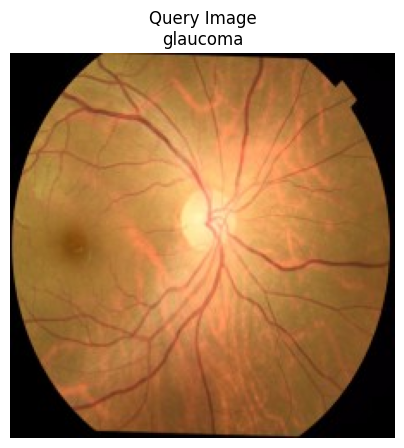

In [76]:
from PIL import Image
import matplotlib.pyplot as plt

query_image = Image.open(query_path).convert("RGB")

plt.figure(figsize=(5, 5))
plt.imshow(query_image)
plt.title(f"Query Image\n{query_label}")
plt.axis("off")
plt.show()

In [77]:
query_embedding = stored_embeddings[query_index]

print("Query embedding shape:", query_embedding.shape)
print(
    "Embedding norm:",
    np.linalg.norm(query_embedding)
)

Query embedding shape: (1280,)
Embedding norm: 1.0000001


In [78]:
similarities = np.dot(
    stored_embeddings,
    query_embedding
)

print("Number of similarity scores:", len(similarities))

print(
    "Highest similarity:",
    similarities.max()
)

Number of similarity scores: 8293
Highest similarity: 1.0000002


In [79]:
TOP_K = 5

sorted_indices = np.argsort(
    similarities
)[::-1]

similar_indices = [
    idx
    for idx in sorted_indices
    if idx != query_index
][:TOP_K]

print("TOP 5 SIMILAR EYE IMAGES")
print("=" * 60)

for rank, idx in enumerate(
    similar_indices,
    start=1
):
    disease = metadata_df.iloc[idx]["label"]
    similarity = similarities[idx]

    print(
        f"{rank}. {disease} "
        f"| Similarity = {similarity:.4f}"
    )

TOP 5 SIMILAR EYE IMAGES
1. glaucoma | Similarity = 0.7348
2. diabetic_retinopathy | Similarity = 0.6931
3. glaucoma | Similarity = 0.6927
4. glaucoma | Similarity = 0.6843
5. Macular Scar | Similarity = 0.6711


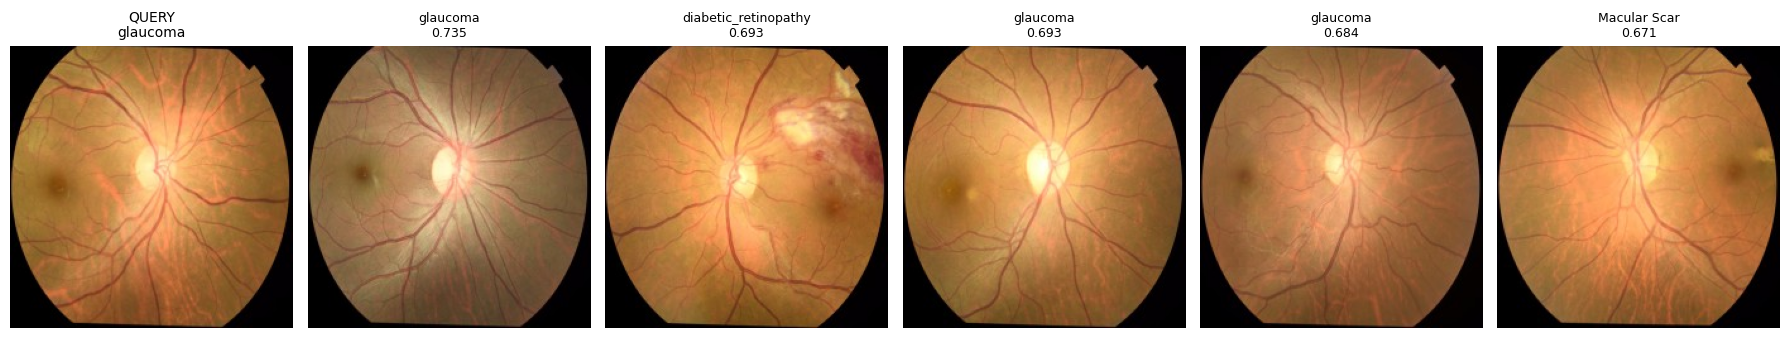

In [80]:
plt.figure(figsize=(18, 6))

# -----------------------
# Query image
# -----------------------

plt.subplot(1, 6, 1)

plt.imshow(query_image)

plt.title(
    f"QUERY\n{query_label}",
    fontsize=10
)

plt.axis("off")


# -----------------------
# Retrieved images
# -----------------------

for position, idx in enumerate(
    similar_indices,
    start=2
):

    similar_path = metadata_df.iloc[idx]["image_path"]

    similar_label = metadata_df.iloc[idx]["label"]

    similarity = similarities[idx]

    similar_image = Image.open(
        similar_path
    ).convert("RGB")

    plt.subplot(
        1,
        6,
        position
    )

    plt.imshow(similar_image)

    plt.title(
        f"{similar_label}\n"
        f"{similarity:.3f}",
        fontsize=9
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [81]:
correct = 0

print("Query disease:", query_label)
print("\nRetrieved diseases:")

for idx in similar_indices:

    retrieved_label = metadata_df.iloc[idx]["label"]

    print("•", retrieved_label)

    if retrieved_label == query_label:
        correct += 1

retrieval_precision = correct / TOP_K

print(
    f"\nPrecision@{TOP_K}: "
    f"{retrieval_precision:.2f}"
)

Query disease: glaucoma

Retrieved diseases:
• glaucoma
• diabetic_retinopathy
• glaucoma
• glaucoma
• Macular Scar

Precision@5: 0.60


In [82]:
!pip install -q neo4j

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.5/331.5 kB 11.2 MB/s eta 0:00:00


In [83]:
from neo4j import GraphDatabase

print("Neo4j driver installed successfully.")

Neo4j driver installed successfully.


In [ ]:
from getpass import getpass

NEO4J_URI = input("Enter Neo4j URI: ")
NEO4J_USERNAME = input("Enter Neo4j username: ")
NEO4J_PASSWORD = getpass("Enter Neo4j password: ")